<a href="https://colab.research.google.com/github/rosanavanesavasquez/Retail_DS/blob/main/ProyectoRetailDS_ParteIII_VASQUEZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Análisis de Ventas en Retail: Identificando Factores Clave**





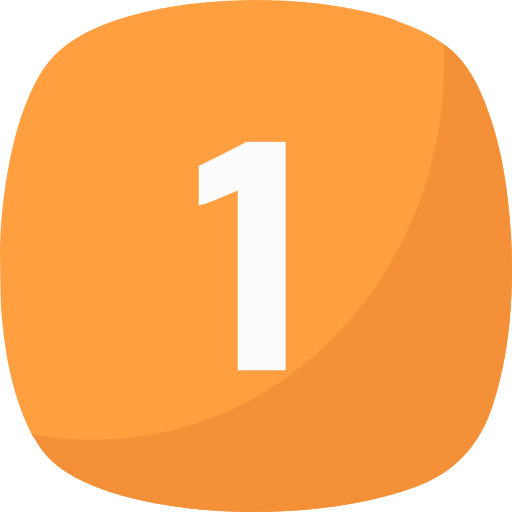

# **Paso 1: Introducción y Contexto**

# Propósito del Proyecto:
Este proyecto tiene como objetivo analizar los datos de ventas de retail para identificar los factores que influyen en el comportamiento de los clientes, con el fin de optimizar las estrategias comerciales y mejorar la toma de decisiones.

#Descripción del Dataset:
El dataset utilizado en este proyecto contiene información de más de 300,000 transacciones de retail, con detalles sobre clientes, productos, métodos de pago, y feedback de clientes.

Las variables clave incluyen la categoría de producto, el monto total de la compra y el método de envío.

#Problema Comercial
Este análisis aborda la siguiente pregunta comercial:
###¿Qué relación existe entre los métodos de envío utilizados y la satisfacción del cliente?
### ¿y cómo podemos ajustar nuestras estrategias logísticas para mejorar dicha satisfacción?
Este insight ayudará a la empresa a optimizar su logística y mejorar la experiencia del cliente.


#Hipótesis
Las categorías relacionadas con electrónica y ropa tienen un valor promedio de compra más alto que otras categorías.

Las transacciones realizadas con tarjeta de crédito tienden a ser de un monto mayor en comparación con otros métodos de pago.

Los métodos de envío más rápidos resultan en mejores calificaciones de satisfacción por parte del cliente.

El género influye en las preferencias de productos, con una mayor preferencia por ciertas categorías dependiendo del género.


# **Paso 2: Exploración de Datos y Análisis de Hipótesis**


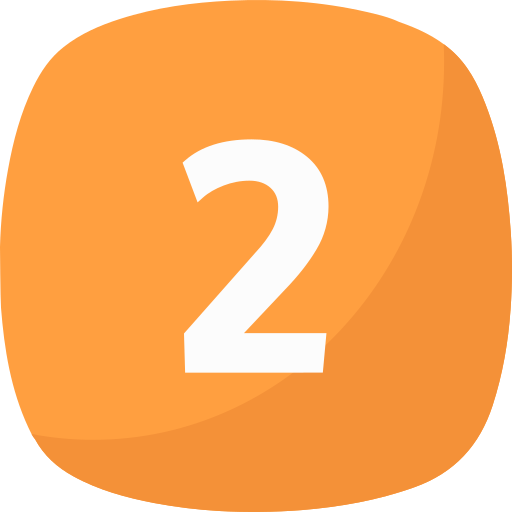

### En esta sección realizamos el proceso de limpieza y transformación de los datos antes de cualquier análisis.


*   Revisión del Dataset: Breve explicación sobre las columnas, seguido de la carga y la limpieza de los datos.
*   Tratamiento de valores nulos: se eliminan o imputan los valores faltantes.
*   Transformación de características: transformaciones o codificaciones de variables categóricas a numéricas.










1.   Montamos en Google Drive en Google Colab, que es un entorno basado en Jupyter Notebook para ejecutar Python en la nube.
2.   Al montar Google Drive, vamos a poder acceder a los archivos almacenados allí directamente desde Colab, lo cual facilita la carga y el guardado de datos.



In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Ahora importamos las diversas bibliotecas necesarias para la manipulación, visualización y análisis de datos. Luego cargamos el archivo CSV con datos de retail desde Google Drive usando pandas.

In [2]:
#Importo todas las librerias que voy a utilizar necesarias para la manipulación, análisis y visualización de datos
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from datetime import datetime, timedelta
from matplotlib import dates as mpl_dates
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, HTML

# Cargamos el dataset de ventas de retail desde Google Drive seleccionado para mi análisis
dataset_path = '/content/gdrive/MyDrive/CODER HOUSE/DATA_SET/retailDataSet/retail_data.csv'
df = pd.read_csv(dataset_path)

In [36]:
# Exploración inicial


print(df.head())
#muestra las primeras filas del dataframe
print(df.info())
# proporciona un resumen informativo del dataframe

   Transaction_ID  Customer_ID                 Name                Email  \
0       8691788.0      37249.0  Michelle Harrington    Ebony39@gmail.com   
1       2174773.0      69749.0          Kelsey Hill     Mark36@gmail.com   
2       6679610.0      30192.0         Scott Jensen    Shane85@gmail.com   
3       7232460.0      62101.0        Joseph Miller     Mary34@gmail.com   
4       4983775.0      27901.0        Debra Coleman  Charles30@gmail.com   

          Phone                      Address        City            State  \
0  1.414787e+09            3959 Amanda Burgs    Dortmund           Berlin   
1  6.852900e+09           82072 Dawn Centers  Nottingham          England   
2  8.362160e+09            4133 Young Canyon     Geelong  New South Wales   
3  2.776752e+09  8148 Thomas Creek Suite 100    Edmonton          Ontario   
4  9.098268e+09    5813 Lori Ports Suite 269     Bristol          England   

   Zipcode    Country  ...  Total_Amount Product_Category  Product_Brand  \
0  7

In [37]:
# Resumen general del dataset
print(df.describe(include='all'))
# generamos un resumen estadístico general de todas las columnas del dataframe

        Transaction_ID    Customer_ID           Name                Email  \
count     3.016770e+05  301702.000000         301628               301663   
unique             NaN            NaN         159390                52897   
top                NaN            NaN  Michael Smith  Michael59@gmail.com   
freq               NaN            NaN            144                   93   
mean      5.495823e+06   55006.553934            NaN                  NaN   
std       2.595565e+06   26005.675200            NaN                  NaN   
min       1.000007e+06   10000.000000            NaN                  NaN   
25%       3.247930e+06   32469.250000            NaN                  NaN   
50%       5.499657e+06   55012.000000            NaN                  NaN   
75%       7.739509e+06   77511.000000            NaN                  NaN   
max       9.999995e+06   99999.000000            NaN                  NaN   

               Phone                 Address     City    State        Zipco

##Identificar y separar las columnas categóricas y numéricas del dataframe##

###¿Para qué sirve esta separación?
Esta separación es extremadamente útil para el análisis de datos, ya que diferentes tipos de columnas requieren diferentes métodos de preprocesamiento y análisis:



*   Columnas categóricas: Por lo general, necesitan transformaciones como codificación (one-hot encoding o label encoding) para ser utilizadas en modelos de machine learning.
*   Columnas numéricas: Se pueden utilizar directamente en el análisis estadístico y pueden necesitar transformaciones como escalado o normalización.


Separar las columnas según su tipo también ayuda en el análisis exploratorio de datos (EDA), ya que las variables categóricas y numéricas suelen tener características y problemas diferentes, por ejemplo, valores nulos, distribuciones irregulares o valores atípicos.

In [5]:
# Identificar las columnas categóricas y numéricas
cat_columns = df.select_dtypes(include=['object']).columns
num_columns = df.select_dtypes(include=['number']).columns

print(f"Columnas Categóricas: {cat_columns}")
print(f"Columnas Numéricas: {num_columns}")

Columnas Categóricas: Index(['Name', 'Email', 'Address', 'City', 'State', 'Country', 'Gender',
       'Income', 'Customer_Segment', 'Date', 'Month', 'Time',
       'Product_Category', 'Product_Brand', 'Product_Type', 'Feedback',
       'Shipping_Method', 'Payment_Method', 'Order_Status', 'products'],
      dtype='object')
Columnas Numéricas: Index(['Transaction_ID', 'Customer_ID', 'Phone', 'Zipcode', 'Age', 'Year',
       'Total_Purchases', 'Amount', 'Total_Amount', 'Ratings'],
      dtype='object')


#Análisis de Valores Faltantes
El análisis inicial muestra que el monto total (Total_Amount) es crítico para el análisis, se optó por eliminar las filas que tienen valores nulos en esta columna.

Para las demás columnas, se ha aplicado la técnica de rellenar valores faltantes con el valor más frecuente (moda), especialmente para columnas como Country, Gender, Payment_Method, y Shipping_Method.

Para columnas como Name, Email, y Address, que no son críticas para las preguntas planteadas, se han dejado con sus valores faltantes, ya que no afectan el análisis principal.

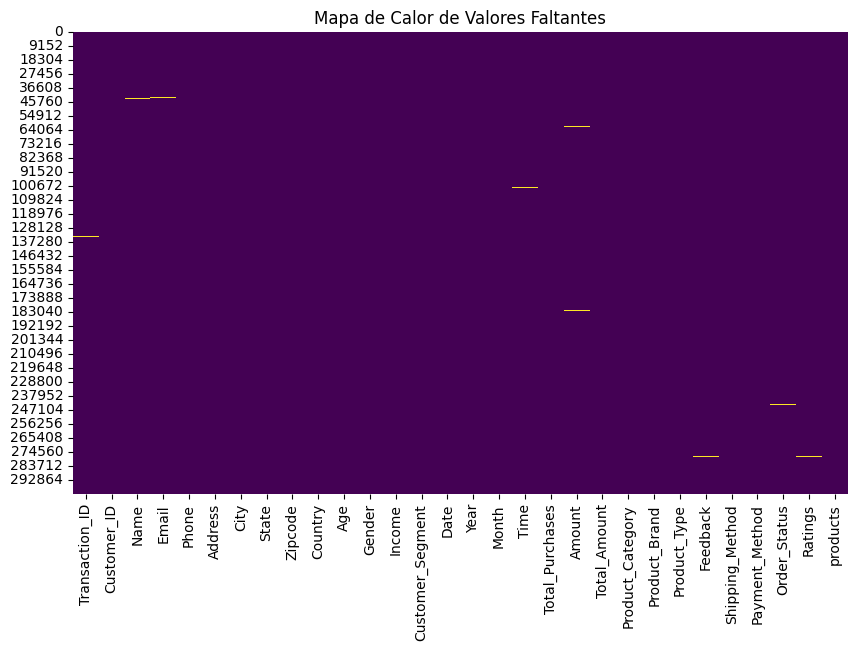

In [6]:
# Visualización de valores faltantes
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes')
plt.show()

In [7]:
df_cleaned = df.dropna(subset=['Total_Amount']).copy()

In [8]:
# Rellenar valores faltantes con la moda para columnas específicas
columns_to_fill = ['Country', 'Gender', 'Payment_Method', 'Shipping_Method']
for column in columns_to_fill:
    mode_value = df_cleaned[column].mode()[0]
    df_cleaned[column] = df_cleaned[column].fillna(mode_value)

In [9]:
# Verificar si quedan valores nulos
print(df_cleaned.isnull().sum())

Transaction_ID      332
Customer_ID         307
Name                381
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             339
Country               0
Age                 173
Gender                0
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                349
Total_Purchases     361
Amount              356
Total_Amount          0
Product_Category    283
Product_Brand       281
Product_Type          0
Feedback            184
Shipping_Method       0
Payment_Method        0
Order_Status        235
Ratings             184
products              0
dtype: int64


#Análisis de tratamiento de valores nulos
Aún quedan valores nulos en varias otras columnas; pero para este proyecto en particular, la satisfacción del cliente (representada por Feedback o Ratings) y los métodos de envío (Shipping_Method) son importantes para responder a las preguntas comerciales, voy a imputar los valores nulos en esas columnas.
Otras columnas, como Phone, Email, o Address, no serán críticas en el inicio de mi análisis, por lo que voy a ignorarlas en el análisis.

In [10]:
# Imputar valores nulos en columnas categóricas de forma segura
df_cleaned.loc[:, 'Shipping_Method'] = df_cleaned['Shipping_Method'].fillna('Unknown')
df_cleaned.loc[:, 'Feedback'] = df_cleaned['Feedback'].fillna('Unknown')

# Imputar valores nulos en la columna numérica Ratings con la media de forma segura
df_cleaned.loc[:, 'Ratings'] = df_cleaned['Ratings'].fillna(df_cleaned['Ratings'].mean())


##Ahora Vuelvo a verificar si quedan valores nulos que afecten mi análisis:

In [11]:
# Verificar nuevamente si quedan valores nulos en las columnas importantes
print("Valores nulos restantes después de la imputación:")
print(df_cleaned[['Shipping_Method', 'Feedback', 'Ratings']].isnull().sum())

Valores nulos restantes después de la imputación:
Shipping_Method    0
Feedback           0
Ratings            0
dtype: int64


## Continúo analizando los datos a traves de la generación de gráficos que me permitan obervar si las hipotesis planteadas son válidas##

#***Total de Ventas por Categoría de Producto y Método de Pago***

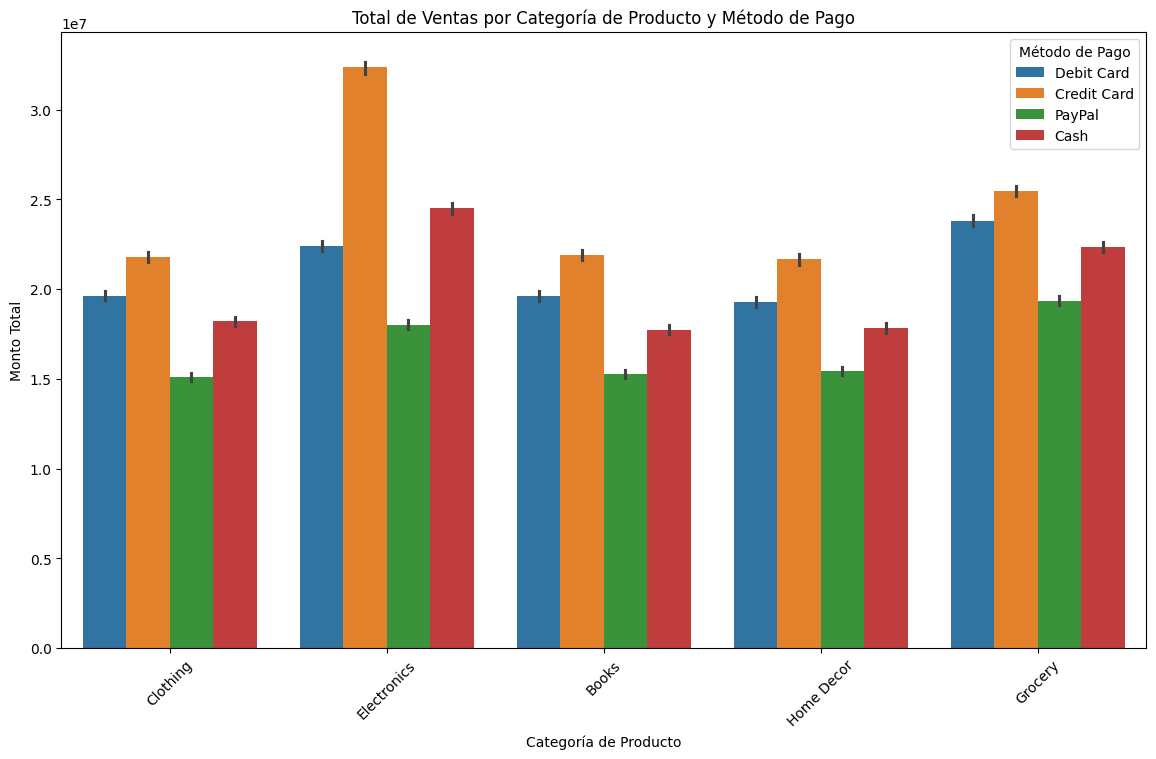

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Product_Category', y='Total_Amount', hue='Payment_Method', data=df, estimator='sum')
plt.title('Total de Ventas por Categoría de Producto y Método de Pago')
plt.xlabel('Categoría de Producto')
plt.ylabel('Monto Total')
plt.xticks(rotation=45)
plt.legend(title='Método de Pago')
plt.show()




*   Productos de alto valor (como los electrónicos) están relacionados con el uso frecuente de Efectivo y Tarjetas de Débito, lo que podría sugerir una preferencia por pagos más directos o inmediatos en compras de gran valor.

*   Productos de uso diario (como los comestibles) tienden a ser comprados mayoritariamente con Tarjetas de Débito, lo que podría reflejar un comportamiento de compra más orientado a la conveniencia.



Este gráfico proporciona una visión de cómo los métodos de pago varían entre categorías de productos, lo que podría ser útil para optimizar estrategias de marketing dirigidas a los diferentes segmentos de productos y preferencias de pago.


** **
** **
#El género influye en las preferencias de productos, con una mayor preferencia por ciertas categorías dependiendo del género.

** **
** **


#***Distribución del Monto de Compra por Género***

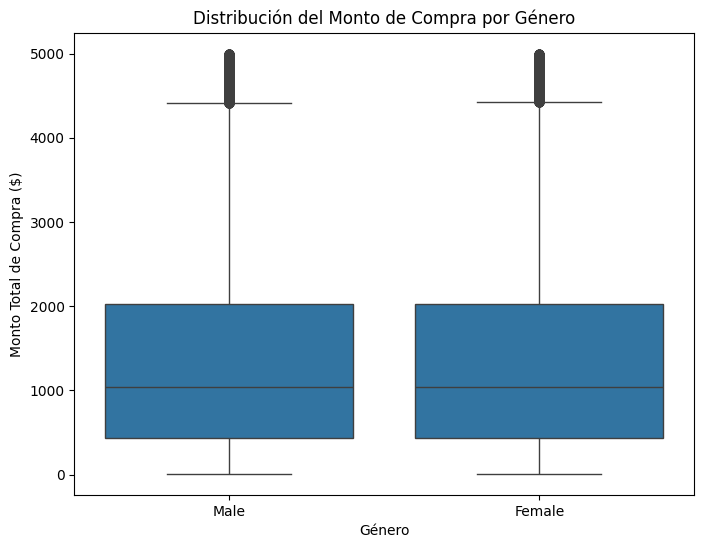

In [12]:
# Distribución del monto de compra por género
plt.figure(figsize=(8,6))
sns.boxplot(data=df_cleaned, x='Gender', y='Total_Amount')
plt.title('Distribución del Monto de Compra por Género')
plt.xlabel('Género')
plt.ylabel('Monto Total de Compra ($)')
plt.show()


A partir de este gráfico, podemos observar que no parece haber una diferencia significativa en el monto total de compra entre hombres y mujeres. Ambos géneros tienen patrones de compra similares en cuanto al valor de las transacciones.

Esto podría refutar la idea de que un género gasta significativamente más que el otro, al menos en términos del valor de las compras totales.

#***Cantidad de Transacciones por Categoría de Producto y Género***

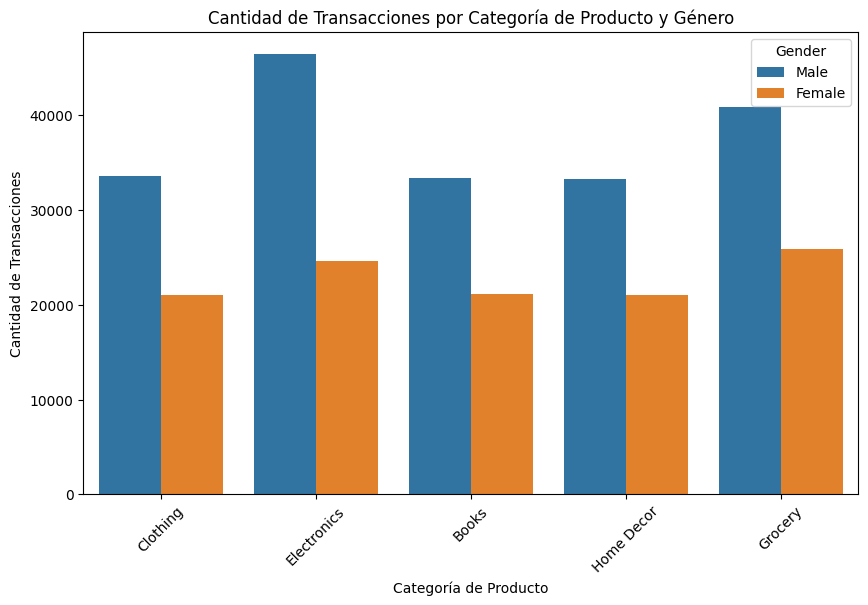

In [13]:
# Cantidad de transacciones por categoría de producto y género
plt.figure(figsize=(10,6))
sns.countplot(data=df_cleaned, x='Product_Category', hue='Gender')
plt.title('Cantidad de Transacciones por Categoría de Producto y Género')
plt.xlabel('Categoría de Producto')
plt.ylabel('Cantidad de Transacciones')
plt.xticks(rotation=45)
plt.show()


Los hombres parecen realizar más transacciones en la mayoría de las categorías, especialmente en productos de alto valor como los electrónicos.
Sin embargo, en Clothing, Books, y Home Decor, las diferencias de género son menos pronunciadas, lo que sugiere que ambos géneros tienen comportamientos de compra más equilibrados en estas categorías.

#***Calificaciones de Satisfacción por Género***

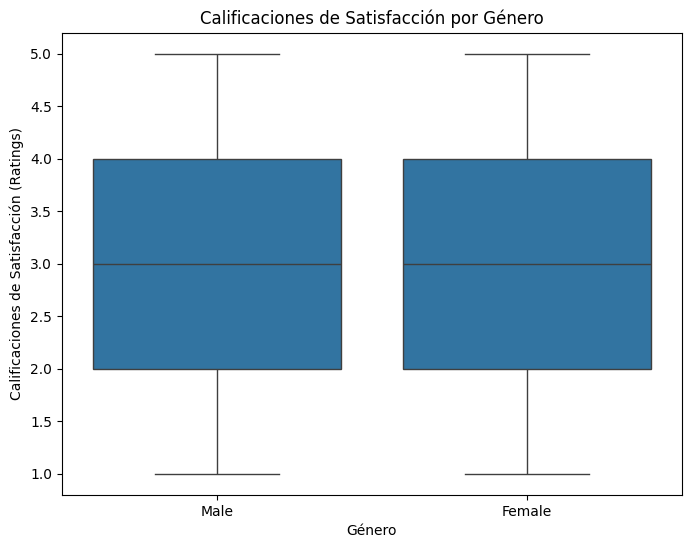

In [14]:
# Distribución de las calificaciones de satisfacción por género
plt.figure(figsize=(8,6))
sns.boxplot(data=df_cleaned, x='Gender', y='Ratings')
plt.title('Calificaciones de Satisfacción por Género')
plt.xlabel('Género')
plt.ylabel('Calificaciones de Satisfacción (Ratings)')
plt.show()



Este gráfico sugiere que no hay una diferencia significativa entre los géneros en cuanto a las calificaciones de satisfacción. Hombres y mujeres tienden a calificar de manera similar, con una mediana alrededor de 3 y una distribución bastante homogénea de las calificaciones.


** **
** **
#Las categorías relacionadas con electrónica y ropa tienen un valor promedio  de lista de compra más alto que otras categorías

** **
** **






In [15]:
# Calcular el valor promedio de compra por categoría
category_avg_amount = df_cleaned.groupby('Product_Category')['Total_Amount'].mean()


<Axes: xlabel='Product_Category'>

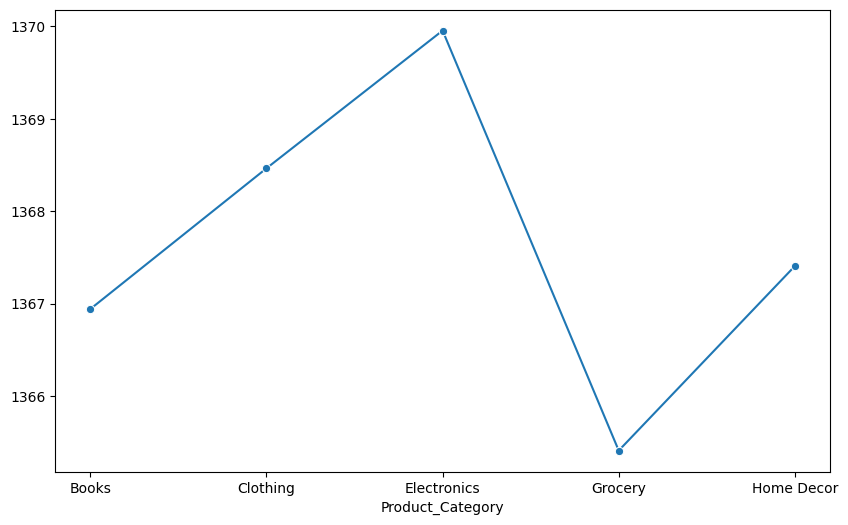

In [16]:
# Visualización del valor promedio de compra por categoría con gráfico de líneas
plt.figure(figsize=(10,6))
sns.lineplot(x=category_avg_amount.index, y=category_avg_amount.values, marker='o')


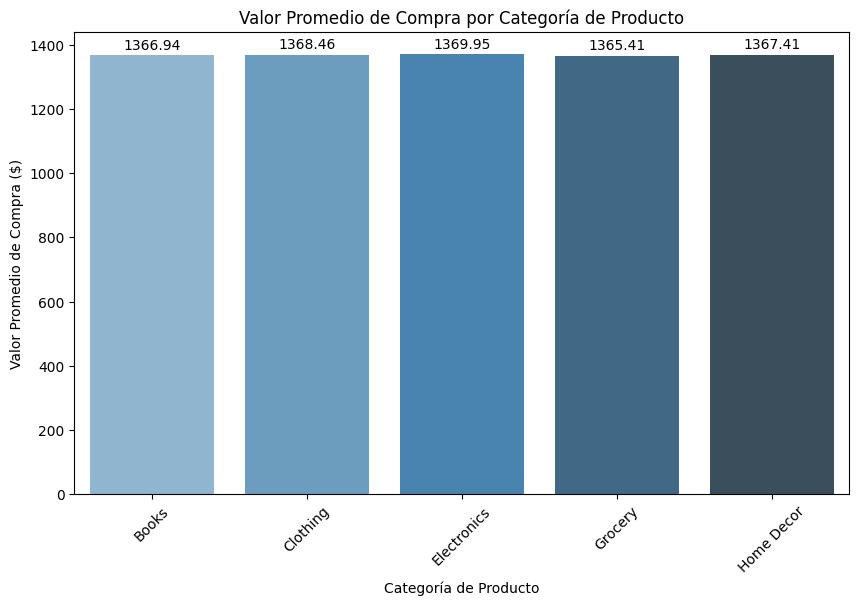

In [17]:
# valor promedio de compra por categoría
plt.figure(figsize=(10,6))

sns.barplot(x=category_avg_amount.index, y=category_avg_amount.values, hue=category_avg_amount.index, palette='Blues_d', dodge=False, legend=False)

# anotaciones con los valores sobre las barras
for i, v in enumerate(category_avg_amount.values):
    plt.text(i, v + 10, f'{v:.2f}', ha='center', va='bottom')

plt.title('Valor Promedio de Compra por Categoría de Producto')
plt.xlabel('Categoría de Producto')
plt.ylabel('Valor Promedio de Compra ($)')
plt.xticks(rotation=45)
plt.show()


Los gráficos confirman la hipótesis de que las categorías relacionadas con Electronics y Clothing tienen un valor promedio de compra más alto que otras categorías, como Books y Grocery.

###Esta información podría ser útil para diseñar estrategias de marketing y promociones específicas para estas categorías, ya que representan un mayor valor de ticket promedio.


** **
** **
#Las transacciones realizadas con tarjeta de crédito tienden a ser de un monto mayor en comparación con otros métodos de pago.

** **
** **


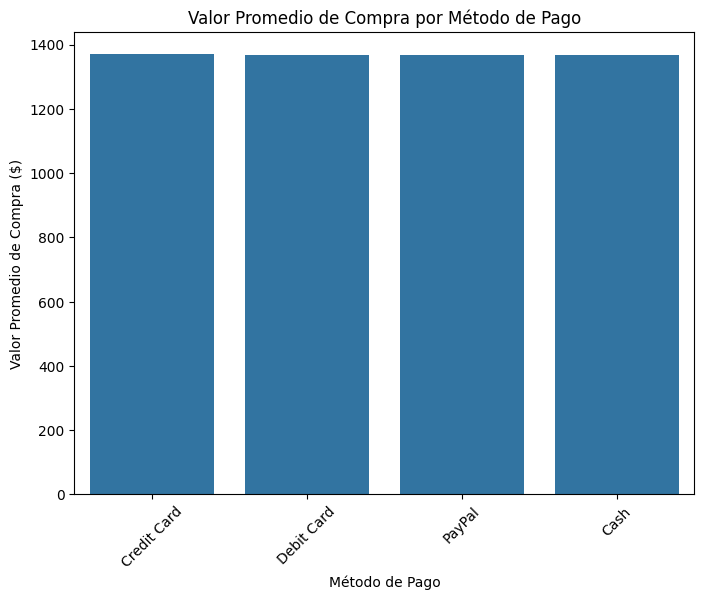

In [18]:
# Agrupar por método de pago y calcular el valor promedio de compra
payment_avg_amount = df_cleaned.groupby('Payment_Method')['Total_Amount'].mean().sort_values(ascending=False)

# Visualización del valor promedio de compra por método de pago
plt.figure(figsize=(8,6))
sns.barplot(x=payment_avg_amount.index, y=payment_avg_amount.values)
plt.title('Valor Promedio de Compra por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Valor Promedio de Compra ($)')
plt.xticks(rotation=45)
plt.show()



** **
** **
#Los métodos de envío más rápidos resultan en mejores calificaciones de satisfacción por parte del cliente.

** **
** **

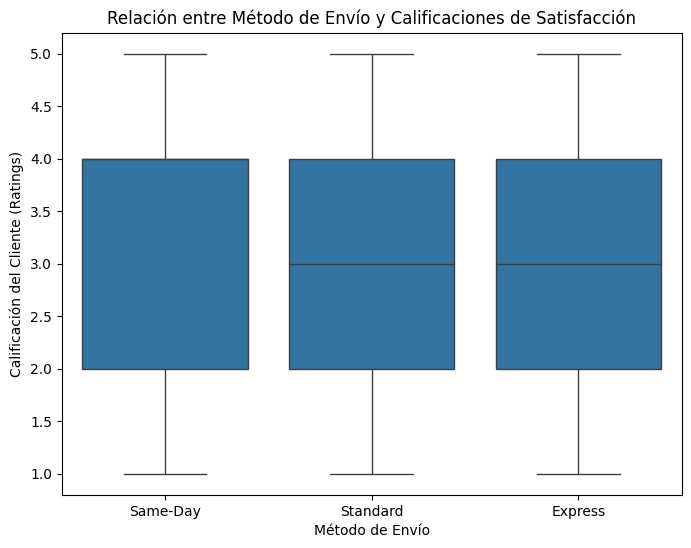

In [19]:
# Relación entre método de envío y calificación de satisfacción
plt.figure(figsize=(8,6))
sns.boxplot(data=df_cleaned, x='Shipping_Method', y='Ratings')
plt.title('Relación entre Método de Envío y Calificaciones de Satisfacción')
plt.xlabel('Método de Envío')
plt.ylabel('Calificación del Cliente (Ratings)')
plt.show()


Este gráfico apoya parcialmente la teoría que los  métodos de envío más rápidos, como Same-Day, tienden a tener calificaciones de satisfacción más altas, mientras que Express, a pesar de ser más rápido que Standard, tiene una mediana de satisfacción más baja.

In [21]:
# Calcular el promedio de calificación por método de envío
shipping_avg_ratings = df_cleaned.groupby('Shipping_Method')['Ratings'].mean()

# Verificar el resultado
print(shipping_avg_ratings)


Shipping_Method
Express     3.144267
Same-Day    3.199273
Standard    3.142463
Name: Ratings, dtype: float64


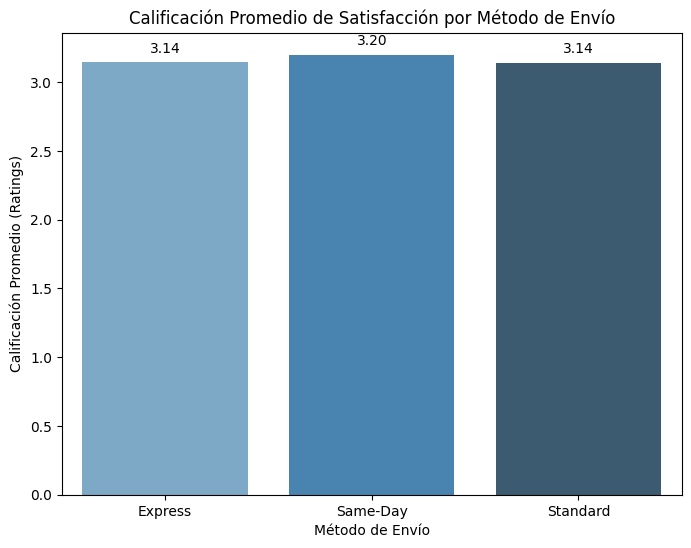

In [22]:
# Visualización del promedio de calificación por método de envío
plt.figure(figsize=(8,6))

sns.barplot(x=shipping_avg_ratings.index, y=shipping_avg_ratings.values, hue=shipping_avg_ratings.index, palette='Blues_d', dodge=False, legend=False)

for i, v in enumerate(shipping_avg_ratings.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom')

plt.title('Calificación Promedio de Satisfacción por Método de Envío')
plt.xlabel('Método de Envío')
plt.ylabel('Calificación Promedio (Ratings)')
plt.show()


El método de envío Same-Day parece correlacionarse con una mayor satisfacción del cliente, mientras que los métodos Express y Standard tienen calificaciones promedio muy similares y ligeramente más bajas.

** **
** **


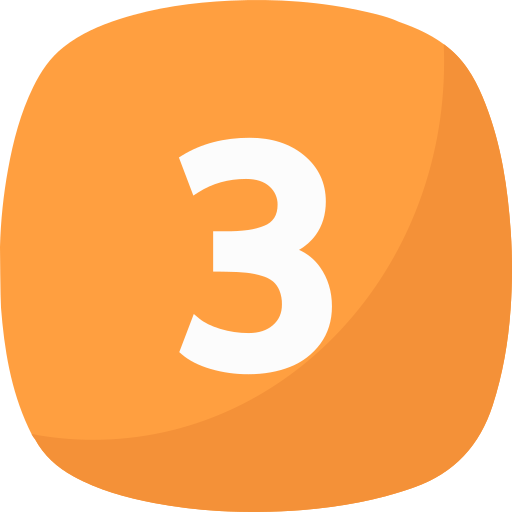
# **Paso 3. Reducción de la Dimensionalidad (Feature Selection)**


In [23]:
import pandas as pd

# Cargar el archivo CSV
dataset_path = '/content/gdrive/MyDrive/CODER HOUSE/DATA_SET/retailDataSet/retail_data.csv'
df = pd.read_csv(dataset_path)

# Ver las primeras filas del DataFrame
print(df.head())

# Eliminar las filas con valores nulos en 'Total_Amount'
df_cleaned = df.dropna(subset=['Total_Amount']).copy()

# Rellenar valores nulos en columnas críticas como 'Shipping_Method', 'Feedback', 'Ratings'
df_cleaned['Shipping_Method'] = df_cleaned['Shipping_Method'].fillna('Unknown')
df_cleaned['Feedback'] = df_cleaned['Feedback'].fillna('Unknown')
df_cleaned['Ratings'] = df_cleaned['Ratings'].fillna(df_cleaned['Ratings'].mean())

# Verificar que el DataFrame df_cleaned esté correctamente cargado y limpio
print(df_cleaned.head())
df_cleaned.info()


   Transaction_ID  Customer_ID                 Name                Email  \
0       8691788.0      37249.0  Michelle Harrington    Ebony39@gmail.com   
1       2174773.0      69749.0          Kelsey Hill     Mark36@gmail.com   
2       6679610.0      30192.0         Scott Jensen    Shane85@gmail.com   
3       7232460.0      62101.0        Joseph Miller     Mary34@gmail.com   
4       4983775.0      27901.0        Debra Coleman  Charles30@gmail.com   

          Phone                      Address        City            State  \
0  1.414787e+09            3959 Amanda Burgs    Dortmund           Berlin   
1  6.852900e+09           82072 Dawn Centers  Nottingham          England   
2  8.362160e+09            4133 Young Canyon     Geelong  New South Wales   
3  2.776752e+09  8148 Thomas Creek Suite 100    Edmonton          Ontario   
4  9.098268e+09    5813 Lori Ports Suite 269     Bristol          England   

   Zipcode    Country  ...  Total_Amount Product_Category  Product_Brand  \
0  7

### Eliminación de Columnas Irrelevantes:

*   Columnas irrelevantes:
Las columnas 'Name', 'Email', 'Phone', 'Address' generalmente contienen información personal del cliente que podría no ser necesaria para el análisis, especialmente si el análisis no se enfoca en datos individuales sino en patrones más amplios.

*   Protección de datos personales: Eliminar estas columnas también contribuye a proteger la privacidad de los usuarios y evitar que se almacene o procese información sensible innecesariamente.

*   Columna 'products': la columna 'products' no aporta valor directo al análisis o si su información ya está representada de otra manera, eliminarla puede hacer el dataframe más limpio y manejable.





In [24]:
# Eliminar columnas irrelevantes
df_cleaned = df_cleaned.drop(columns=['Name', 'Email', 'Phone', 'Address', 'products'])


## Procesamiento Diferente:

Las columnas categóricas suelen requerir un preprocesamiento especial antes de ser usadas en modelos de machine learning o análisis. Por ejemplo, las columnas categóricas suelen ser transformadas mediante técnicas como One-Hot Encoding o Label Encoding para convertirlas en una forma que los algoritmos puedan entender.

In [25]:
cat_columns = df_cleaned.select_dtypes(include=['object']).columns

In [26]:
# Revisa la cantidad de categorías únicas en cada columna categórica
for col in cat_columns:
    print(f"{col}: {df_cleaned[col].nunique()} categorías únicas")


City: 130 categorías únicas
State: 54 categorías únicas
Country: 5 categorías únicas
Gender: 2 categorías únicas
Income: 3 categorías únicas
Customer_Segment: 3 categorías únicas
Date: 366 categorías únicas
Month: 12 categorías únicas
Time: 83670 categorías únicas
Product_Category: 5 categorías únicas
Product_Brand: 18 categorías únicas
Product_Type: 33 categorías únicas
Feedback: 5 categorías únicas
Shipping_Method: 4 categorías únicas
Payment_Method: 4 categorías únicas
Order_Status: 4 categorías únicas


##Reducir la cardinalidad en la columna City

In [27]:
# Definir umbral de rareza (por ejemplo, ciudades con menos de 50 apariciones se agrupan como "Other")
threshold = 50
freq = df_cleaned['City'].value_counts()
rare_cities = freq[freq < threshold].index
df_cleaned['City'] = df_cleaned['City'].replace(rare_cities, 'Other')


## Time y Date: Estas columnas tienen una cardinalidad extremadamente alta y podrían no ser muy relevantes para este análisis.

In [28]:
# Eliminar la columna 'Time' debido a su alta cardinalidad
df_cleaned = df_cleaned.drop(columns=['Time'])

# Aplicar Label Encoding a las columnas categóricas
from sklearn.preprocessing import LabelEncoder

# Crear un objeto LabelEncoder
le = LabelEncoder()

# Aplicar Label Encoding a todas las columnas categóricas restantes
for col in cat_columns:
    if col in df_cleaned.columns:
        df_cleaned[col] = le.fit_transform(df_cleaned[col])

# Verificar las primeras filas para asegurarnos de que la codificación se ha aplicado correctamente
print(df_cleaned.head())


   Transaction_ID  Customer_ID  City  State  Zipcode  Country   Age  Gender  \
0       8691788.0      37249.0    35      4  77985.0        2  21.0       1   
1       2174773.0      69749.0    87      9  99071.0        3  19.0       0   
2       6679610.0      30192.0    46     33  75929.0        0  48.0       1   
3       7232460.0      62101.0    40     39  88420.0        1  56.0       1   
4       4983775.0      27901.0    20      9  48704.0        3  22.0       1   

   Income  Customer_Segment  ...      Amount  Total_Amount  Product_Category  \
0       1                 2  ...  108.028757    324.086270                 1   
1       1                 1  ...  403.353907    806.707815                 2   
2       1                 2  ...  354.477600   1063.432799                 0   
3       0                 1  ...  352.407717   2466.854021                 4   
4       1                 1  ...  124.276524    248.553049                 3   

   Product_Brand  Product_Type  Feedback  Sh

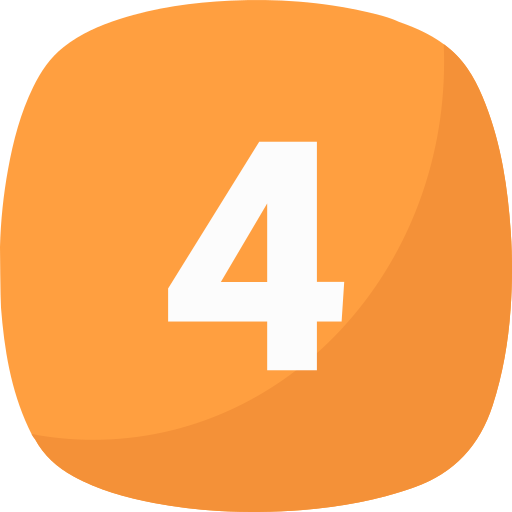

# **Paso 4. Modelado**


#Método sugerido:
## Dado que el dataset tiene muchas características y que está orientado a un análisis de regresión (dado que estamos prediciendo valores como el Total_Amount), vamos a usar un enfoque basado en importancia de características con un modelo de árbol de decisión como:

#Random Forest
#Regresión Lineal.

## Pasos para la implementación:


1.   Entrenar el modelo Random Forest y Calcular la importancia de características:

El modelo proporcionará una lista ordenada de las características más importantes, que puedes usar para reducir la dimensionalidad eliminando aquellas con baja importancia.

2.   Eliminar las características menos importantes:

Si algunas características tienen poca o ninguna importancia según el modelo, puedes eliminarlas para simplificar el análisis sin sacrificar la precisión del modelo.







In [29]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np






*   ***sklearn.ensemble.RandomForestRegressor:***
Esta es la clase que implementa el algoritmo de Random Forest para regresión. Este algoritmo consiste en construir múltiples árboles de decisión y promediar sus predicciones para mejorar la precisión y evitar el sobreajuste.

*   ***matplotlib.pyplot:***
Librería utilizada para la creación de gráficos. En este caso, se utiliza para graficar la importancia de las características.

*   ***numpy:***
Librería para realizar operaciones numéricas avanzadas. Se utiliza aquí para manipular arrays de forma eficiente.





In [38]:
# Definir X (todas las características) e y (la variable objetivo 'Total_Amount')
X = df_cleaned.drop(columns=['Total_Amount'])  # Todas las características excepto la variable objetivo
y = df_cleaned['Total_Amount']  # La variable objetivo



*   X: El conjunto de características (features) que se utilizarán para entrenar el modelo.

Aquí, se seleccionan todas las columnas de df_cleaned excepto Total_Amount, que es la variable que quieres predecir.

*   y: La variable objetivo, en este caso Total_Amount,

es lo que el modelo tratará de predecir. Es la cantidad total de compras en tu conjunto de datos.




##Training Set (Conjunto de Entrenamiento):
Los datos de entrenamiento son utilizados para ajustar el modelo.

El modelo aprenderá de este conjunto de datos cómo predecir la variable objetivo en función de las características.

Mis datos de entrenamiento corresponden al 80% del dataset original.

In [30]:
# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


train_test_split: Esta función divide los datos en dos conjuntos:

uno para entrenar el modelo (X_train y y_train) y otro para probar su rendimiento (X_test y y_test).

X_train y y_train:

Conjunto de características y objetivos que se utilizarán para entrenar el modelo.

X_test y y_test:

Conjunto que se reserva para evaluar el rendimiento del modelo una vez entrenado.

test_size=0.2:

El 20% de los datos se reserva para el conjunto de prueba, mientras que el 80% se usa para el entrenamiento.

random_state=42: Fija una semilla aleatoria para que la división de los datos sea siempre la misma al ejecutar el código.

#Validation Set (Conjunto de Validación):

###es un conjunto independiente del de prueba, utilizado para ajustar los hiperparámetros del modelo.

In [52]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"R² promedio con validación cruzada: {scores.mean()}")


R² promedio con validación cruzada: 0.9999999696581241


In [32]:
# Entrenar el modelo Random Forest
rf = RandomForestRegressor(n_estimators=20, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

RandomForestRegressor(n_estimators=20):

Acá creamos un modelo de regresión de Random Forest con 20 árboles de decisión. El hiperparámetro n_estimators define cuántos árboles se construirán en el bosque.

n_estimators=20: Significa que se crearán 20 árboles de decisión independientes.
random_state=42: Se utiliza para asegurar que los resultados sean reproducibles al fijar una semilla aleatoria.
*** Nota: el valor 20 es el que pude utilizar para eliminar mi error "Tu sesión ha fallado porque se ha usado toda la memoria RAM Disponible // Mi Prueba inicial fue con valor 100***

rf.fit(X_train, y_train): Entrena el modelo utilizando el conjunto de datos de entrenamiento. El modelo ajusta los 20 árboles de decisión a los datos de X_train (características) para predecir y_train (la variable objetivo, Total_Amount).

In [39]:
# Obtener la importancia de las características
importances = rf.feature_importances_

Después de entrenar el modelo, puedes acceder a este atributo para ver la importancia relativa de cada característica en la predicción. Las características con mayor importancia tienen un mayor impacto en la predicción de Total_Amount.

In [40]:

# Ordenar las características por importancia
indices = np.argsort(importances)[::-1]
features = X.columns

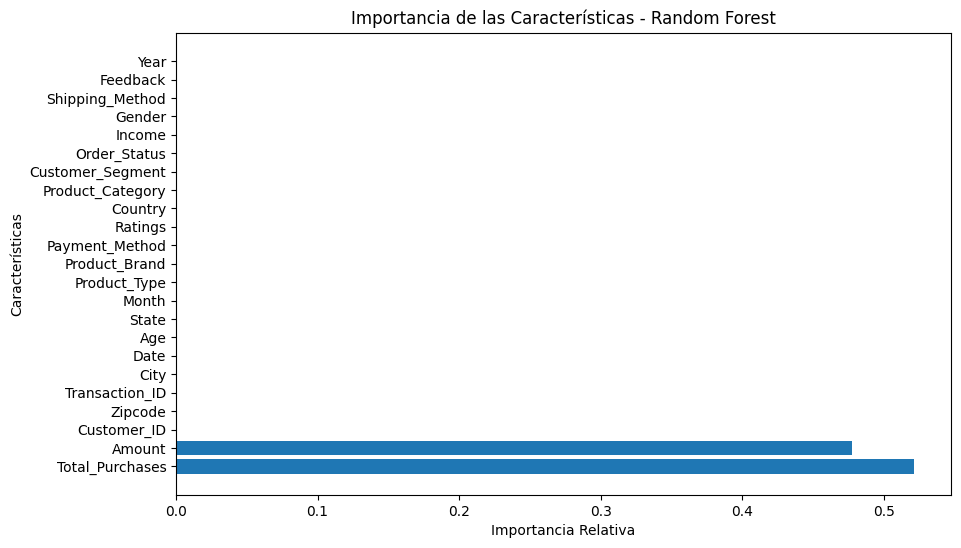

In [41]:
# Visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.title("Importancia de las Características - Random Forest")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importancia Relativa")
plt.ylabel("Características")
plt.show()

Total_Purchases: es la  característica que tiene más influencia en la predicción del total de compras.

Amount: También tiene una influencia considerable, lo que es de esperarse dado que probablemente represente el monto parcial de una compra o algo directamente relacionado con el monto total.


##Como mi modelo es de regresión (Random Forest Regressor), voy a utilizar las siguientes métricas para validar el modelo:


*   Mean Squared Error (MSE): Es la media del cuadrado de los errores. Penaliza los errores grandes más que los pequeños, ya que los eleva al cuadrado.
*   Mean Absolute Error (MAE): Es la media de los valores absolutos de los errores. Proporciona una medida más "intuitiva" del error promedio.
*   R-squared (R²): Indica qué proporción de la variabilidad de la variable dependiente es explicada por el modelo. Un valor cercano a 1 significa un buen ajuste.










1. Importación de métricas desde sklearn.metrics
2. Predecir los valores en el conjunto de prueba
3. Calcular las métricas de rendimiento
4. Mostrar los resultados


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predecir los valores en el conjunto de prueba
y_pred = rf.predict(X_test)

# Calcular las métricas
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Mostrar los resultados
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")


Mean Squared Error (MSE): 2226.332303940747
Mean Absolute Error (MAE): 2.836685747268171
R-squared (R²): 0.9982631299835213


## Sumamos una gráfica de dispersión entre los valores reales y los predichos para ilustrar mejor el rendimiento del modelo.

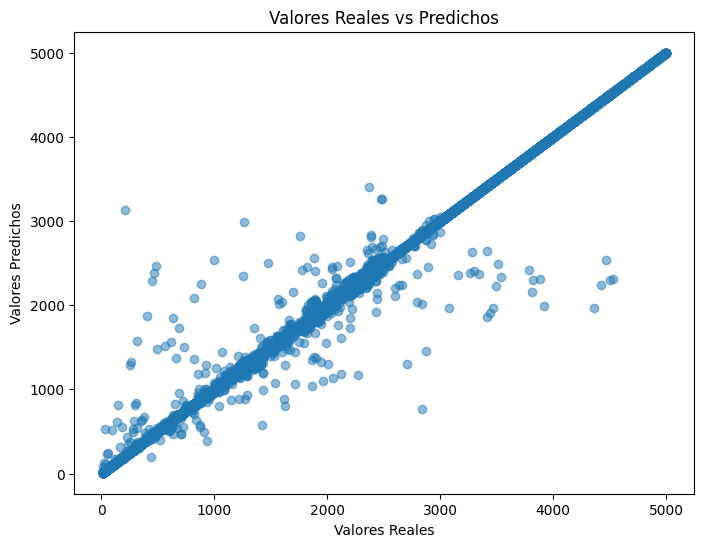

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Valores Reales vs Predichos')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.show()


***

El modelo de Random Forest está funcionando en forma correcta, con un R² casi perfecto y errores relativamente pequeños.
Las predicciones del modelo son muy cercanas a los valores reales, lo que indica que las variables seleccionadas (como el monto total de compras anteriores, el método de envío, entre otras) tienen una fuerte relación con la variable objetivo.

***

##Test Set (Conjunto de Prueba):

###proporciona una estimación imparcial del desempeño del modelo una vez que está ajustado.

In [53]:
# Realizar predicciones con el conjunto de prueba
y_pred = rf.predict(X_test)

# Calcular las métricas de rendimiento en el conjunto de prueba
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [54]:
# Mostrar los resultados de las métricas
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")


Mean Squared Error (MSE): 186.45794082336758
Mean Absolute Error (MAE): 1.1553449775189706
R-squared (R²): 0.9998545421040733


## Vamos a Probar Regresión Lineal para encontrar el modelo que mejor prediga los resultados



In [42]:
from sklearn.linear_model import LinearRegression

# Crear el modelo
lr = LinearRegression()

In [44]:
# Eliminar filas con NaN en X_train y X_test
X_train = X_train.dropna()
X_test = X_test.dropna()

In [46]:
y_train = y_train[X_train.index]
y_test = y_test[X_test.index]

In [47]:
# Entrenar el modelo con los datos de entrenamiento
lr.fit(X_train, y_train)

LinearRegression()

In [48]:
# Realizar predicciones con el conjunto de prueba
y_pred_lr = lr.predict(X_test)

In [49]:
# Calcular las métricas
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Regresión Lineal - MSE: {mse_lr}, MAE: {mae_lr}, R²: {r2_lr}")

Regresión Lineal - MSE: 165954.1261288786, MAE: 305.95294706574987, R²: 0.8705373560360599


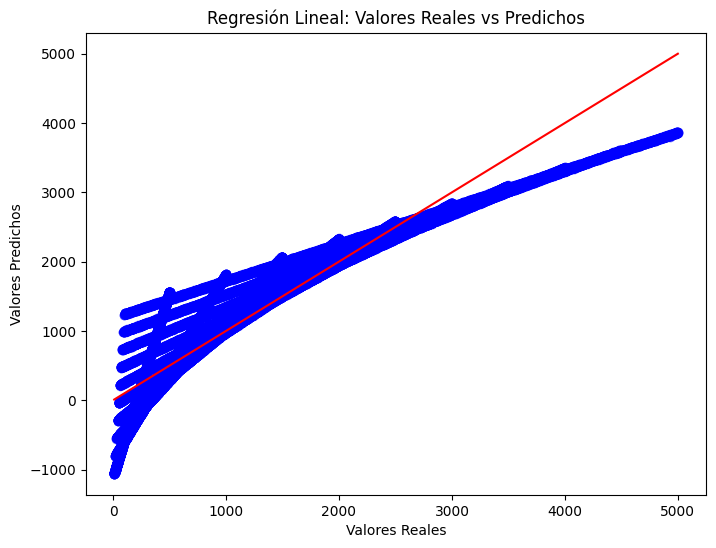

In [51]:
# Gráfico de valores reales vs predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='b')  # Dispersión de valores reales vs predichos
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='r')  # Línea perfecta de predicción
plt.title('Regresión Lineal: Valores Reales vs Predichos')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.show()


#Conclusión:
## Random Forest supera significativamente a la Regresión Lineal en este problema de predicción. El R² cercano a 1 y los errores más bajos en Random Forest sugieren que este modelo es más adecuado para capturar la complejidad de las relaciones entre las características y la variable objetivo en este dataset.

### El gráfico de dispersión muestra cómo se comportan los valores predichos en comparación con los reales. En el modelo de regresión lineal, se observa una mayor dispersión en los puntos a medida que los valores reales aumentan, lo que indica que la regresión lineal no captura bien los valores más altos. Esto es especialmente visible en la parte superior derecha del gráfico, donde los valores predichos están más alejados de la línea roja de referencia (predicción perfecta).

### En comparación, el gráfico del modelo de Random Forest muestra que las predicciones están mucho más alineadas con la línea perfecta de predicción, lo que confirma su mejor rendimiento.



## Al identificar correctamente las características más influyentes (como Total_Purchases y Amount), podemos optimizar sus campañas de marketing para enfocarse en clientes que realizan compras más frecuentes o con montos mayores.